<font size = 8 color ='336EFF'>Hill Climbing</font>

Import Libraries

In [ ]:
# hill climbing search of a one-dimensional objective function
from numpy import asarray
from numpy import arange
from numpy.random import randn
from numpy.random import rand
from numpy.random import seed
from matplotlib import pyplot as plt
from IPython import display
%matplotlib inline

#Define Objective Function

In [ ]:
# objective function
def objective(x):
    return (x[0] - 2)*(x[0] - 1)*(x[0] + 1)*(x[0] + 3)-10#x[0]**2.0

Define auxiliary function for plotting

In [ ]:
def plotCurrentSolution(bounds, candidate, bestSolution):
    # sample input range uniformly at 0.1 increments
    inputs = arange(bounds[0,0], bounds[0,1], 0.1)
    # create a line plot of input vs result
    plt.clf()
    plt.plot(inputs, [objective([x]) for x in inputs], '--')
    # draw a vertical line at the optimal input
    plt.axvline(x=[0.0], ls='--', color='red')
    # plot the sample as black circles
    plt.plot(candidate, objective(candidate), 'o', color='black')
    plt.plot(bestSolution, objective(bestSolution), 'o', color='red')
    plt.draw()#plt.show()
    display.display(plt.gcf())
    display.clear_output(wait=True)
    plt.pause(0.1)

# Define Hill Climbing function

In [ ]:
# hill climbing local search algorithm
def hillclimbing(objective, bounds, n_iterations, step_size):
    # generate an initial point
    solution = bounds[:, 0] + rand(len(bounds)) * (bounds[:, 1] - bounds[:, 0])
    # evaluate the initial point
    solution_eval = objective(solution)
    # run the hill climb
    solutions = list()
    solutions.append(solution)
    for i in range(n_iterations):
        # take a step
        candidate = solution + randn(len(bounds)) * step_size
        # evaluate candidate point
        candidte_eval = objective(candidate)
        # check if we should keep the new point
        if candidte_eval <= solution_eval:
            # store the new point
            solution, solution_eval = candidate, candidte_eval
            # keep track of solutions
            solutions.append(solution)
            # report progress
            print('>%d f(%s) = %.5f' % (i, solution, solution_eval))
        plotCurrentSolution(bounds, candidate, solution)

    return [solution, solution_eval, solutions]


Define Main Function

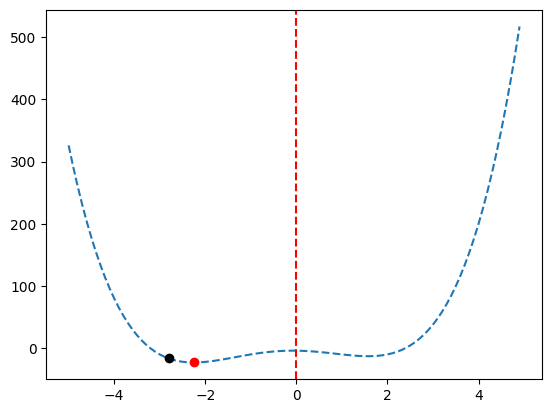

Done!
f([-2.25291796]) = -22.949442


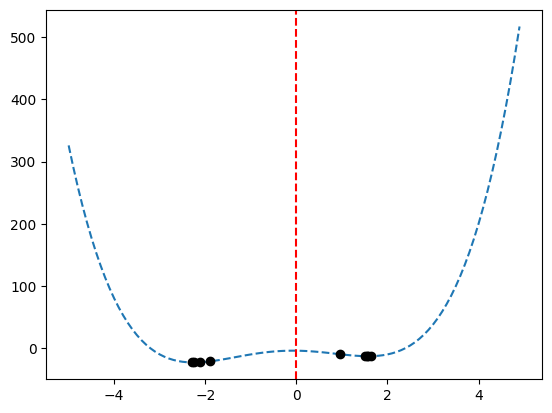

In [ ]:
# seed the pseudorandom number generator
# seed(5)
# define range for input
bounds = asarray([[-5.0, 5.0]])
# define the maximum number of iterations
n_iterations = 100
# define the maximum step size
step_size = 0.1
# perform the hill climbing search
best, score, solutions = hillclimbing(objective, bounds, n_iterations, step_size)
print('Done!')
print('f(%s) = %f' % (best, score))

# sample input range uniformly at 0.1 increments
inputs = arange(bounds[0,0], bounds[0,1], 0.1)
# create a line plot of input vs result
plt.plot(inputs, [objective([x]) for x in inputs], '--')
# draw a vertical line at the optimal input
plt.axvline(x=[0.0], ls='--', color='red')
# plot the sample as black circles
plt.plot(solutions, [objective(x) for x in solutions], 'o', color='black')
plt.show()